# Regresión lineal para predicción de progresión de diabetes
- age: Representa la edad del paciente, normalizada (no es la edad real, sino una representación estandarizada).
- sex: Sexo del paciente, representado como una variable numérica normalizada (valores entre -0.5 y 0.5).
- bmi: Índice de Masa Corporal (Body Mass Index, BMI), una medida del peso relativo al cuadrado de la altura.
- bp:
Promedio de presión arterial (Blood Pressure, BP), normalizada.
- s1: Nivel sérico de lípidos totales (colesterol total).
- s2: Nivel sérico de lipoproteínas de baja densidad (LDL, “colesterol malo”).
- s3: Nivel sérico de lipoproteínas de alta densidad (HDL, “colesterol bueno”).
- s4: Relación entre el colesterol total y HDL.
- s5: Nivel sérico de triglicéridos, representado como una medida numérica normalizada.
- s6: Nivel sérico de glucosa en ayuno, una medida clave en el monitoreo de la diabetes.

In [2]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Cargar el conjunto de datos
diabetes_data = load_diabetes()

# Convertir el conjunto de datos a un DataFrame para facilitar su manipulación
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target  # Agregar la variable objetivo al DataFrame

# Mostrar las primeras filas del DataFrame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
#Importamos librerías para el modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Separamos las características X y la variable objetivo Y
X = df.drop('target', axis=1)
y = df['target']

#Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Creamos el model de regresión lineal
modelo = LinearRegression()

#Entrenamos el modelo
modelo.fit(X_train, y_train)

#Realizamos predicciones
y_pred = modelo.predict(X_test)

#Evaluamos el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error cuadrático medio (MSE): ", mse)
print("Coeficiente de determinación (R2): ", r2)

Error cuadrático medio (MSE):  2900.1936284934814
Coeficiente de determinación (R2):  0.4526027629719195


X contiene las características médicas: edad, sexo, IMC, presión arterial y otras variables
y contiene target, que representa la progresión de la diabetes
train_test_split() divide los datos en un conjunto para entrenar y otro para evaluar
LinearRegression() crea el modelo de regresión lineal
fit() entrena el modelo con los datos
predict() genera las predicciones
MSE mide el error de las predicciones; cuanto menor sea, mejor es la predicción
R2 indica qué tan bien explica el modelo la variación de la variable objetivo, cuanto más cercano sea a 1 mejor

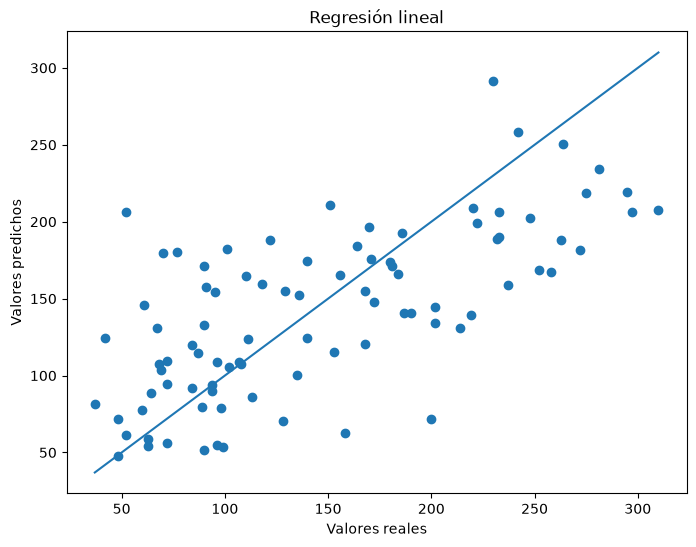

In [6]:
#Creamos una gráfica de los valores reales vs. predichos
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión lineal")

#Línea ideal donde predicción = valor real
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])

plt.show()

In [7]:
#Revisamos los coeficientes del modelo, el cual indica cómo se relaciona cada característica con la predicción del modelo, manteniendo las demás variables constatntes
coeficientes = pd.DataFrame({
    'Característica': X.columns,
    'Coeficiente': modelo.coef_
})